In [ ]:

import pandas as pd
import matplotlib.pyplot as plt


df = pd.read_csv('std_performance.csv')
print(df.head())

   student_id    name gender  maths  physics  chemistry  attendance
0           1    Amit      M     78       85         80          92
1           2   Priya      F     88       90         91          95
2           3   Rahul      M     45       50         48          70
3           4  Anjali      F     92       88         90          98
4           5  Vikram      M     60       65         63          80


In [4]:
print(df.columns)

Index(['student_id', 'name', 'gender', 'maths', 'physics', 'chemistry',
       'attendance'],
      dtype='str')


In [7]:
print(df.isnull().value_counts())

student_id  name   gender  maths  physics  chemistry  attendance
False       False  False   False  False    False      False         100
Name: count, dtype: int64


In [8]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   student_id  100 non-null    int64
 1   name        100 non-null    str  
 2   gender      100 non-null    str  
 3   maths       100 non-null    int64
 4   physics     100 non-null    int64
 5   chemistry   100 non-null    int64
 6   attendance  100 non-null    int64
dtypes: int64(5), str(2)
memory usage: 5.6 KB
None


In [9]:
print(df.dtypes)

student_id    int64
name            str
gender          str
maths         int64
physics       int64
chemistry     int64
attendance    int64
dtype: object


In [ ]:
print(df['gender'].value_counts())

gender
M    50
F    50
Name: count, dtype: int64


In [12]:
print(df['chemistry'].mean())

71.95


In [13]:
print(df['maths'].mean())

71.76


In [14]:
print(df['physics'].mean())

73.39


In [19]:
df['total_marks'] = df[['maths','physics','chemistry']].sum(axis=1)
print(df.head())

   student_id    name gender  maths  physics  chemistry  attendance  \
0           1    Amit      M     78       85         80          92   
1           2   Priya      F     88       90         91          95   
2           3   Rahul      M     45       50         48          70   
3           4  Anjali      F     92       88         90          98   
4           5  Vikram      M     60       65         63          80   

   total_marks  
0          243  
1          269  
2          143  
3          270  
4          188  


In [22]:
df['average_marks'] = df['total_marks']/3
df['result'] = df['total_marks'].apply(lambda x:'Pass' if x >= 150 else 'Fail')
print(df.head())

   student_id    name gender  maths  physics  chemistry  attendance  \
0           1    Amit      M     78       85         80          92   
1           2   Priya      F     88       90         91          95   
2           3   Rahul      M     45       50         48          70   
3           4  Anjali      F     92       88         90          98   
4           5  Vikram      M     60       65         63          80   

   total_marks  average_marks result  
0          243      81.000000   Pass  
1          269      89.666667   Pass  
2          143      47.666667   Fail  
3          270      90.000000   Pass  
4          188      62.666667   Pass  


In [23]:
print(df['result'].value_counts())

result
Pass    89
Fail    11
Name: count, dtype: int64


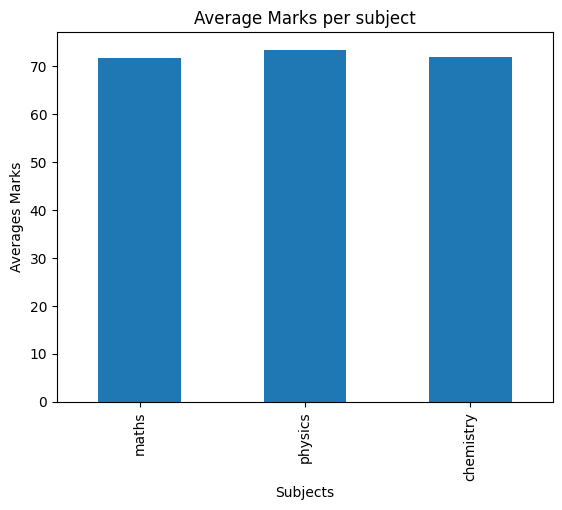

In [26]:
subject_avg=df[['maths','physics','chemistry']].mean()
subject_avg.plot(kind='bar')
plt.title('Average Marks per subject')
plt.xlabel('Subjects')
plt.ylabel('Averages Marks')
plt.show()

In [29]:
result_counts = df['result'].value_counts()
print(result_counts)

result
Pass    89
Fail    11
Name: count, dtype: int64


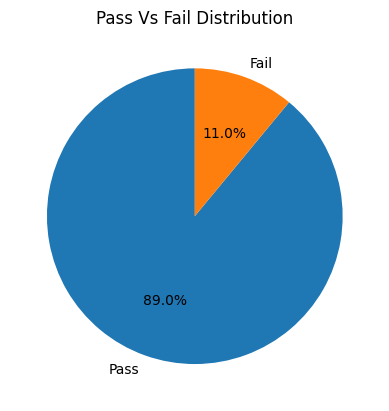

In [34]:
import matplotlib.pyplot as plt

plt.pie(
    result_counts,
    labels=result_counts.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title('Pass Vs Fail Distribution')
plt.show()

In [36]:
top_students = df.sort_values(by='total_marks',ascending=False).head(5)
print(top_students[['name','gender','total_marks','average_marks']])

         name gender  total_marks  average_marks
99      Pooja      F          285           95.0
49  Priyanshi      F          285           95.0
29       Lata      F          282           94.0
79      Nisha      F          282           94.0
89      Heena      F          282           94.0


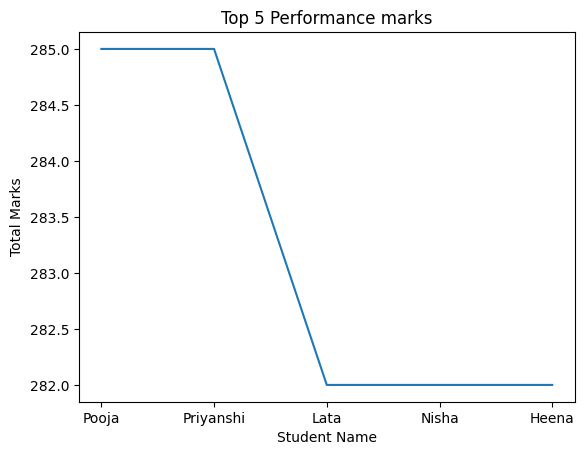

In [37]:
plt.plot(top_students['name'],top_students['total_marks'])
plt.title('Top 5 Performance marks')
plt.ylabel('Total Marks')
plt.xlabel('Student Name')
plt.show()

In [38]:
gender_performance = df.groupby('gender')['average_marks'].mean()
print(gender_performance)

gender
F    86.766667
M    57.966667
Name: average_marks, dtype: float64


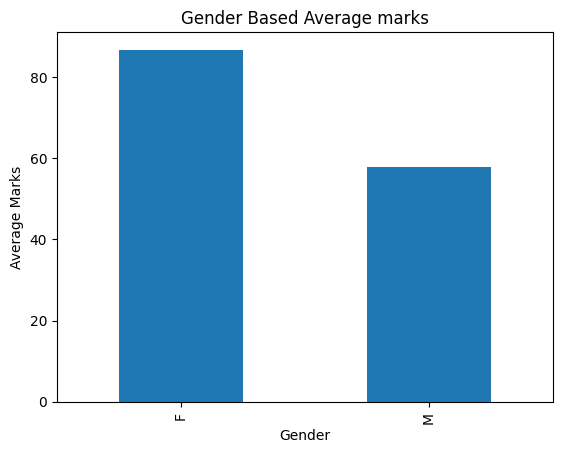

In [39]:
gender_performance.plot(kind='bar')
plt.title('Gender Based Average marks')
plt.ylabel('Average Marks')
plt.xlabel('Gender')
plt.show()

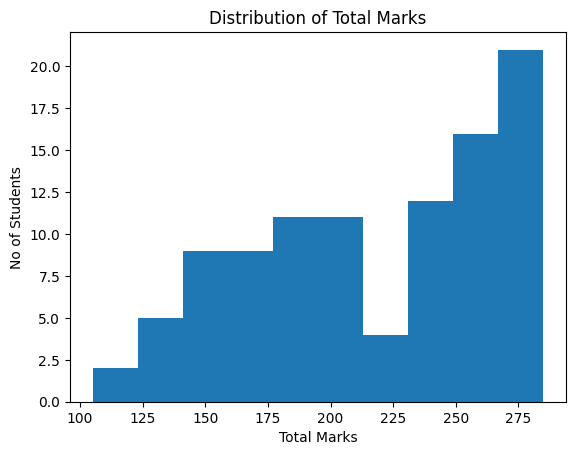

In [40]:
plt.hist(df['total_marks'],bins=10)
plt.title('Distribution of Total Marks')
plt.xlabel('Total Marks')
plt.ylabel('No of Students')
plt.show()

C:\Users\Rakes\AppData\Local\Temp\ipykernel_6524\1473905046.py:1: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


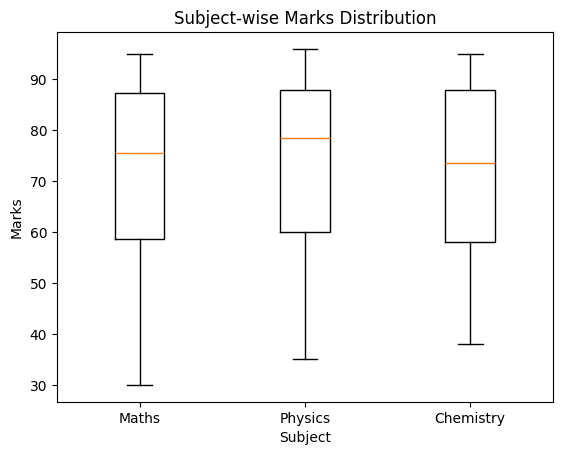

In [41]:
plt.boxplot(
    [df['maths'], df['physics'], df['chemistry']],
    labels=['Maths', 'Physics', 'Chemistry']
)
plt.title('Subject-wise Marks Distribution')
plt.ylabel('Marks')
plt.xlabel('Subject')
plt.show()
